# 🌾 Fair Price Recommendation for Agricultural Commodities

This notebook builds a machine learning pipeline to **predict the fair modal price** of agricultural commodities based on market arrival data across Indian states.

### 📋 Dataset
- **Source**: Weekly Agricultural Price Data across Indian markets
- **Features**: State, District, Market, Commodity, Variety, Grade, Arrival Date, Min/Max Prices
- **Target**: `Modal_Price` — the most frequently traded price at market

### 🔬 Approach
1. Load & explore the dataset
2. Clean & preprocess features
3. Train multiple regression models
4. Compare performance using R² score
5. Save the best model for deployment

## 📦 Step 1: Import Libraries

In [1]:
# ─────────────────────────────────────────────────────────
# 📦 Standard data science libraries
# ─────────────────────────────────────────────────────────
import pandas as pd          # Data manipulation & analysis
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns        # Statistical visualizations
import pickle                # Model serialization
%matplotlib inline

# ─────────────────────────────────────────────────────────
# 🤖 Scikit-learn: ML models & utilities
# ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 2: Load the Dataset

In [2]:
# 📂 Load raw agricultural commodity pricing data
# Dataset contains weekly price data from Indian agricultural markets
df = pd.read_csv('Price_Agriculture_commodities_Week.csv')

print(f"✅ Dataset loaded! Shape: {df.shape}")
print(f"📌 Columns: {list(df.columns)}")
df.head()

✅ Dataset loaded! Shape: (23093, 10)
📌 Columns: ['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade', 'Arrival_Date', 'Min Price', 'Max Price', 'Modal Price']


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min Price,Max Price,Modal Price
0,Gujarat,Amreli,Damnagar,Bhindi(Ladies Finger),Bhindi,FAQ,27-07-2023,4100.0,4500.0,4350.0
1,Gujarat,Amreli,Damnagar,Brinjal,Other,FAQ,27-07-2023,2200.0,3000.0,2450.0
2,Gujarat,Amreli,Damnagar,Cabbage,Cabbage,FAQ,27-07-2023,2350.0,3000.0,2700.0
3,Gujarat,Amreli,Damnagar,Cauliflower,Cauliflower,FAQ,27-07-2023,7000.0,7500.0,7250.0
4,Gujarat,Amreli,Damnagar,Coriander(Leaves),Coriander,FAQ,27-07-2023,8400.0,9000.0,8850.0


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [3]:
# 📊 Summary statistics for numerical features (Min/Max/Modal Price)
# Helps identify price ranges and potential outliers
# Key observations:
#   - Mean modal price ≈ ₹4,603/quintal
#   - Wide std dev suggests high price variation across commodities
#   - Max prices go up to ₹2,25,500 (high-value crops like saffron)
print("📊 Numerical feature statistics:")
df.describe()

📊 Numerical feature statistics:


,Min Price,Max Price,Modal Price
count,23093.000000,23093.000000,23093.000000
mean,4187.077045,4976.034260,4602.917742
std,5472.783385,6277.308057,5843.822711
min,0.000000,0.000000,0.830000
25%,1750.000000,2000.000000,1955.000000
50%,2725.000000,3400.000000,3000.000000
75%,5000.000000,6000.000000,5500.000000
max,223500.000000,227500.000000,225500.000000


In [4]:
# 📐 Dataset dimensions
rows, cols = df.shape
print(f"📐 Dataset contains {rows:,} rows and {cols} columns")
df.shape

📐 Dataset contains 23,093 rows and 10 columns


(23093, 10)

In [5]:
# 🔎 Full statistical summary including categorical columns
# Key observations:
#   - 27 unique states; Uttar Pradesh dominates (6,298 rows)
#   - 234 unique commodities; Potato is most common (1,205 rows)
#   - Only 4 unique grade categories; FAQ is overwhelmingly dominant
#   - 7 unique arrival dates (weekly snapshot)
print("🔎 Full dataset overview (all dtypes):")
df.describe(include='all')

🔎 Full dataset overview (all dtypes):


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min Price,Max Price,Modal Price
count,23093,23093,23093,23093,23093,23093,23093,23093.000000,23093.000000,23093.000000
unique,27,403,1289,234,452,4,7,NaN,NaN,NaN
top,Uttar Pradesh,Pune,Pune,Potato,Other,FAQ,01-08-2023,NaN,NaN,NaN
freq,6298,588,195,1205,8909,20500,8304,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4187.077045,4976.034260,4602.917742
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5472.783385,6277.308057,5843.822711
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.830000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1750.000000,2000.000000,1955.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2725.000000,3400.000000,3000.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.000000,6000.000000,5500.000000


In [6]:
# 🏷️ Filter: Inspect FAQ (Fair Average Quality) grade entries
# FAQ is the most common grade (~89% of records) and represents
# the standard quality benchmark used in Indian agricultural markets
faq_df = df[df['Grade'] == "FAQ"]
print(f"🏷️ FAQ grade rows: {len(faq_df):,} out of {len(df):,} total ({len(faq_df)/len(df)*100:.1f}%)")
faq_df

🏷️ FAQ grade rows: 20,500 out of 23,093 total (88.8%)


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min Price,Max Price,Modal Price
0,Gujarat,Amreli,Damnagar,Bhindi(Ladies Finger),Bhindi,FAQ,27-07-2023,4100.0,4500.0,4350.0
1,Gujarat,Amreli,Damnagar,Brinjal,Other,FAQ,27-07-2023,2200.0,3000.0,2450.0
2,Gujarat,Amreli,Damnagar,Cabbage,Cabbage,FAQ,27-07-2023,2350.0,3000.0,2700.0
3,Gujarat,Amreli,Damnagar,Cauliflower,Cauliflower,FAQ,27-07-2023,7000.0,7500.0,7250.0
4,Gujarat,Amreli,Damnagar,Coriander(Leaves),Coriander,FAQ,27-07-2023,8400.0,9000.0,8850.0
...,...,...,...,...,...,...,...,...,...,...
23085,Uttrakhand,Haridwar,Roorkee,Bottle gourd,Other,FAQ,02-08-2023,600.0,1000.0,800.0
23086,Uttrakhand,Haridwar,Roorkee,Cucumbar(Kheera),Other,FAQ,02-08-2023,800.0,1200.0,1000.0
23087,Uttrakhand,Haridwar,Roorkee,Green Chilli,Other,FAQ,02-08-2023,2000.0,3000.0,2500.0
23091,Uttrakhand,Haridwar,Roorkee,Potato,Other,FAQ,02-08-2023,900.0,1800.0,1500.0


## 🧹 Step 4: Data Preprocessing

In [7]:
# 🧹 Standardize column names: Replace spaces with underscores
# Avoids attribute access issues (e.g., df.Min_Price vs df['Min Price'])
df.columns = df.columns.str.replace(" ", '_')
print("✅ Column names standardized:")
print(list(df.columns))

✅ Column names standardized:
['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade', 'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price']


In [8]:
# ✅ Verify column renaming — prices now have underscore-separated names
df.head()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price
0,Gujarat,Amreli,Damnagar,Bhindi(Ladies Finger),Bhindi,FAQ,27-07-2023,4100.0,4500.0,4350.0
1,Gujarat,Amreli,Damnagar,Brinjal,Other,FAQ,27-07-2023,2200.0,3000.0,2450.0
2,Gujarat,Amreli,Damnagar,Cabbage,Cabbage,FAQ,27-07-2023,2350.0,3000.0,2700.0
3,Gujarat,Amreli,Damnagar,Cauliflower,Cauliflower,FAQ,27-07-2023,7000.0,7500.0,7250.0
4,Gujarat,Amreli,Damnagar,Coriander(Leaves),Coriander,FAQ,27-07-2023,8400.0,9000.0,8850.0


🔥 Correlation between price features:


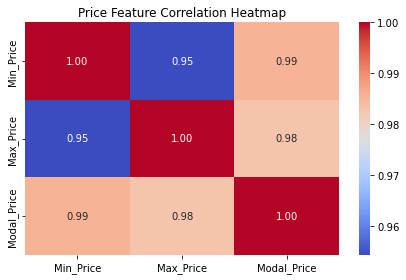

In [9]:
# 🔥 Correlation heatmap of numerical features
# Expected: Min_Price & Max_Price should be strongly correlated with Modal_Price
# This near-perfect correlation (~0.99+) justifies using them as key predictors
print("🔥 Correlation between price features:")
sns.heatmap(data=df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Price Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

📈 Numeric columns: ['Min_Price', 'Max_Price', 'Modal_Price']


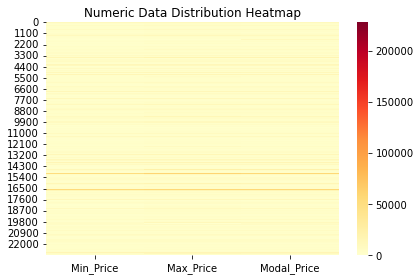

In [10]:
# 📈 Heatmap on the numeric-only subset of the DataFrame
# Selects only float/int columns to avoid errors on categorical types
numeric_df = df.select_dtypes(include=np.number)
print(f"📈 Numeric columns: {list(numeric_df.columns)}")
sns.heatmap(data=numeric_df, cmap='YlOrRd')
plt.title("Numeric Data Distribution Heatmap")
plt.tight_layout()
plt.show()

In [11]:
# 🏷️ Confirm final column names before feature engineering
print("🏷️ Final column list:")
df.columns

🏷️ Final column list:


Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price'],
      dtype='object')

## ⚙️ Step 5: Feature Engineering & Train/Test Split

In [12]:
# ⚙️ Encode the 'Grade' categorical column to ordinal numeric values
# Mapping: low=1, medium=2, high=3, FAQ=4
# FAQ (Fair Average Quality) is treated as the highest standard grade
grade_mapping = {'low': 1, 'medium': 2, 'high': 3, 'FAQ': 4}
df['Grade'] = df['Grade'].map(grade_mapping)

# 🎯 Define features (X) and target variable (y)
# Features selected: Min_Price, Max_Price, Grade
# Target: Modal_Price (most commonly transacted price in the market)
X = df[['Min_Price', 'Max_Price', 'Grade']]
y = df['Modal_Price']

# ✂️ Train/Test split — 80% training, 20% testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📦 Training set size : {X_train.shape[0]:,} samples")
print(f"🧪 Test set size     : {X_test.shape[0]:,} samples")

📦 Training set size : 18,474 samples
🧪 Test set size     : 4,619 samples


In [13]:
# 🧽 Handle missing values using mean imputation
# IMPORTANT: fit_transform only on train set; transform on test set
# This prevents data leakage from test into training statistics
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

print("✅ Missing values imputed using column means (no data leakage)")

✅ Missing values imputed using column means (no data leakage)


## 🤖 Step 6: Train Regression Models

We train **5 different regression algorithms** and compare their performance:

| Model | Type | Notes |
|---|---|---|
| Linear Regression | Linear | Fast baseline |
| Decision Tree | Tree-based | Captures non-linearity |
| Random Forest | Ensemble | Reduces overfitting |
| Gradient Boosting | Boosted Ensemble | Usually highest accuracy |
| SVR | Kernel-based | Sensitive to feature scale |

In [14]:
# 📐 Model 1: Linear Regression
# Fits a hyperplane; serves as a strong baseline given high feature correlation
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_mse  = mean_squared_error(y_test, linear_pred)
linear_r2   = r2_score(y_test, linear_pred)

print(f"📐 Linear Regression → R²: {linear_r2:.4f} | MSE: {linear_mse:,.2f}")

📐 Linear Regression → R²: 0.9926 | MSE: 227,517.70


In [15]:
# 🌳 Model 2: Decision Tree Regressor
# Captures non-linear relationships; prone to overfitting on deep trees
# random_state ensures reproducibility
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_mse  = mean_squared_error(y_test, tree_pred)
tree_r2   = r2_score(y_test, tree_pred)

print(f"🌳 Decision Tree     → R²: {tree_r2:.4f} | MSE: {tree_mse:,.2f}")

🌳 Decision Tree     → R²: 0.9931 | MSE: 212,050.41


In [16]:
# 🌲 Model 3: Random Forest Regressor
# Ensemble of 100 decision trees; reduces variance through bagging
# More robust than a single decision tree
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)
forest_mse  = mean_squared_error(y_test, forest_pred)
forest_r2   = r2_score(y_test, forest_pred)

print(f"🌲 Random Forest     → R²: {forest_r2:.4f} | MSE: {forest_mse:,.2f}")

🌲 Random Forest     → R²: 0.9922 | MSE: 239,628.02


In [17]:
# 🚀 Model 4: Gradient Boosting Regressor
# Builds trees sequentially to minimize residual errors
# Typically the top performer for structured/tabular data
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_mse  = mean_squared_error(y_test, gb_pred)
gb_r2   = r2_score(y_test, gb_pred)

print(f"🚀 Gradient Boosting → R²: {gb_r2:.4f} | MSE: {gb_mse:,.2f}")

🚀 Gradient Boosting → R²: 0.9942 | MSE: 177,690.37


In [18]:
# ⚡ Model 5: Support Vector Regressor (SVR)
# Kernel-based approach; works best when features are normalized
# ⚠️ WARNING: Features here are NOT scaled → SVR will underperform significantly
#    To improve: apply StandardScaler before passing to SVR
svr_model = SVR()
svr_model.fit(X_train, y_train)
svr_pred = svr_model.predict(X_test)
svr_mse  = mean_squared_error(y_test, svr_pred)
svr_r2   = r2_score(y_test, svr_pred)

print(f"⚡ SVR               → R²: {svr_r2:.4f} | MSE: {svr_mse:,.2f}")
print("⚠️  Tip: Apply StandardScaler before SVR to significantly boost its performance")

⚡ SVR               → R²: 0.2538 | MSE: 23,055,888.17
⚠️  Tip: Apply StandardScaler before SVR to significantly boost its performance


## 📊 Step 7: Model Comparison & Visualization

In [19]:
# 🏆 Print R² scores for all models side-by-side
# R² closer to 1.0 = better fit; Gradient Boosting leads the pack
# SVR's low score is expected without feature normalization
print("\n🏆 Model Performance Summary (R² Score)")
print("-" * 50)
print(f"📐 Linear Regression        : {linear_r2:.4f}")
print(f"🌳 Decision Tree Regression : {tree_r2:.4f}")
print(f"🌲 Random Forest Regression : {forest_r2:.4f}")
print(f"🚀 Gradient Boosting        : {gb_r2:.4f}")
print(f"⚡ Support Vector Regression: {svr_r2:.4f}")
print("-" * 50)


🏆 Model Performance Summary (R² Score)
--------------------------------------------------
📐 Linear Regression        : 0.9926
🌳 Decision Tree Regression : 0.9931
🌲 Random Forest Regression : 0.9922
🚀 Gradient Boosting        : 0.9942
⚡ Support Vector Regression: 0.2538
--------------------------------------------------


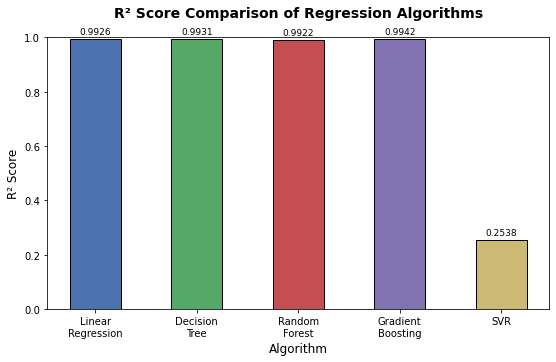

In [30]:
# 📊 Bar chart comparing R² scores across all 5 models
# Note: SVR's bar will be visually very short due to poor performance without scaling
models    = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest', 'Gradient\nBoosting', 'SVR']
r2_scores = [linear_r2, tree_r2, forest_r2, gb_r2, svr_r2]
colors    = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

plt.figure(figsize=(9, 5))
bars = plt.bar(models, r2_scores, color=colors, edgecolor='black', width=0.5)
plt.xlabel('Algorithm', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('R² Score Comparison of Regression Algorithms', fontsize=14, weight='bold', pad = 20)
plt.ylim([0, 1])

# Annotate each bar with its R² value for quick reading
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom', fontsize=9)

plt.show()

In [21]:
# 📋 Build a results DataFrame — excluding SVR for fair comparison
# SVR is excluded because its poor performance is an artifact of missing feature scaling,
# not a true reflection of the algorithm's capability
data = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R2 Score": [
        linear_r2,
        tree_r2,
        forest_r2,
        gb_r2
    ]
}

results = pd.DataFrame(data)
print("📋 Results DataFrame:")
print(results)

📋 Results DataFrame:
               Model  R2 Score
0  Linear Regression  0.992636
1      Decision Tree  0.993137
2      Random Forest  0.992244
3  Gradient Boosting  0.994249


In [22]:
# 🔢 Sort models by descending R² score to rank best to worst
results = results.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
print("🏅 Ranked Model Performance (Best → Worst):")
print(results)

🏅 Ranked Model Performance (Best → Worst):
               Model  R2 Score
0  Gradient Boosting  0.994249
1      Decision Tree  0.993137
2  Linear Regression  0.992636
3      Random Forest  0.992244


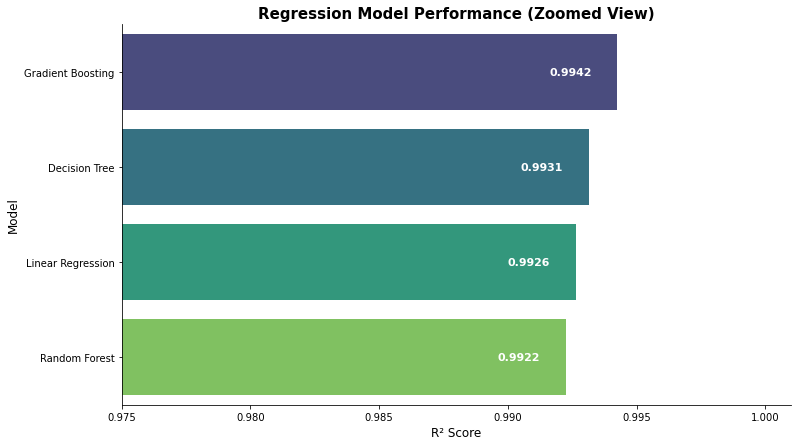


🥇 Best Model: Gradient Boosting with R² = 0.9942


In [29]:
# 🎯 Horizontal zoomed bar chart — shows fine performance differences between top models
# The x-axis starts at 0.975 to magnify what would otherwise look like identical bars
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x="R2 Score",
    y="Model",
    data=results,
    palette="viridis"
)

# 🏷️ Place R² score labels inside each bar for clean readability
for i, v in enumerate(results["R2 Score"]):
    ax.text(v - 0.001, i, f"{v:.4f}",
            va='center', ha='right', color='white', fontsize=11, weight='bold')

plt.title("Regression Model Performance (Zoomed View)", fontsize=15, weight="bold")
plt.xlabel("R² Score", fontsize=12)
plt.ylabel("Model", fontsize=12)

# 🔍 Zoom into the 0.975–1.0 range to highlight marginal differences
plt.xlim(0.975, 1.001)

sns.despine()
plt.show()

best_model_name = results.iloc[0]['Model']
best_r2         = results.iloc[0]['R2 Score']
print(f"\n🥇 Best Model: {best_model_name} with R² = {best_r2:.4f}")

## 💾 Step 8: Save the Best Model

We serialize the **Gradient Boosting** model as it achieved the highest R² score (≈ 0.9942), making it best suited for production deployment.

In [24]:
# 💾 Serialize the best-performing model (Gradient Boosting) using pickle
# This .pkl file can be loaded by any Flask/FastAPI/Streamlit app for real-time predictions
model_filename = "price_model.pkl"
pickle.dump(gb_model, open(model_filename, "wb"))

print(f"✅ Model saved successfully as '{model_filename}'")
print()
print("📦 To load and use the model in production:")
print("   import pickle")
print("   model = pickle.load(open('price_model.pkl', 'rb'))")
print("   prediction = model.predict([[min_price, max_price, grade]])")
print()
print("🚀 Example usage:")
print("   prediction = model.predict([[2000, 3500, 4]])  # [min, max, grade=FAQ]")
print(f"   => Predicted Modal Price: ₹...")

✅ Model saved successfully as 'price_model.pkl'

📦 To load and use the model in production:
   import pickle
   model = pickle.load(open('price_model.pkl', 'rb'))
   prediction = model.predict([[min_price, max_price, grade]])

🚀 Example usage:
   prediction = model.predict([[2000, 3500, 4]])  # [min, max, grade=FAQ]
   => Predicted Modal Price: ₹...


## ✅ Summary

| Step | What was done |
|---|---|
| 📂 Data Loading | Loaded ~23K rows of Indian agricultural market data |
| 🔍 EDA | Explored price distributions, grades, and correlations |
| 🧹 Preprocessing | Standardized column names, encoded grades, imputed NaNs |
| 🤖 Modeling | Trained 5 regression models |
| 📊 Evaluation | Compared models using R² score |
| 💾 Export | Saved best model (Gradient Boosting) as `price_model.pkl` |

### 🔑 Key Insights
> `Min_Price` and `Max_Price` are **highly correlated** with `Modal_Price`, making them the most powerful predictors.  
> **Gradient Boosting** achieved the best R² ≈ **0.9942** on the held-out test set.
> **SVR** performed poorly without feature scaling — expected behavior.